In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")
pd.set_option("display.max_columns",None)

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Rows :",df.shape[0])

print("Columns :",df.shape[1])

df.info()

Rows : 200
Columns : 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
print("""

Business Problem

Businesses often treat every customer the same.

However, customers have different purchasing behaviors.

Using clustering techniques, we can group customers into meaningful segments
and design personalized marketing strategies.

""")



Business Problem

Businesses often treat every customer the same.

However, customers have different purchasing behaviors.

Using clustering techniques, we can group customers into meaningful segments
and design personalized marketing strategies.




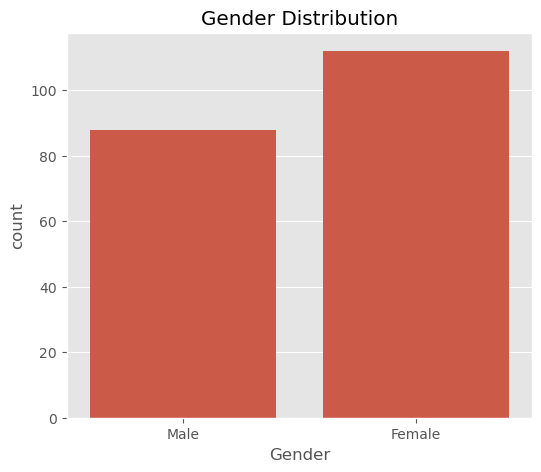

In [8]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Gender Distribution")

plt.show()

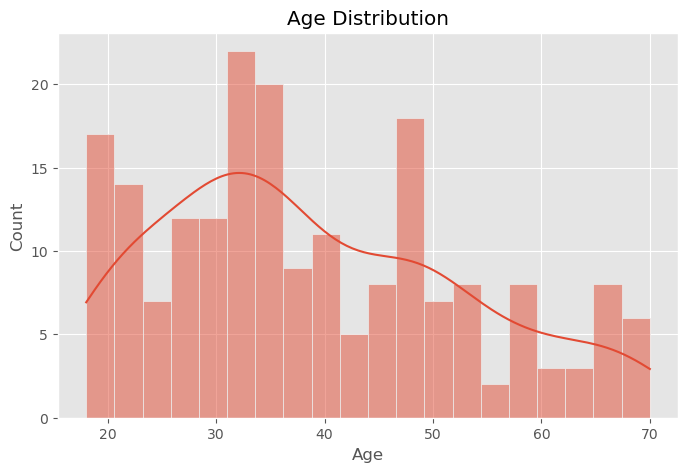

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

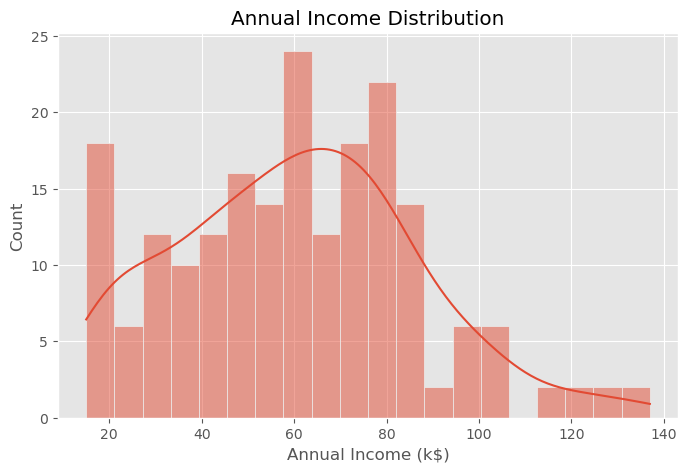

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Annual Income (k$)"],
    bins=20,
    kde=True
)

plt.title("Annual Income Distribution")

plt.show()

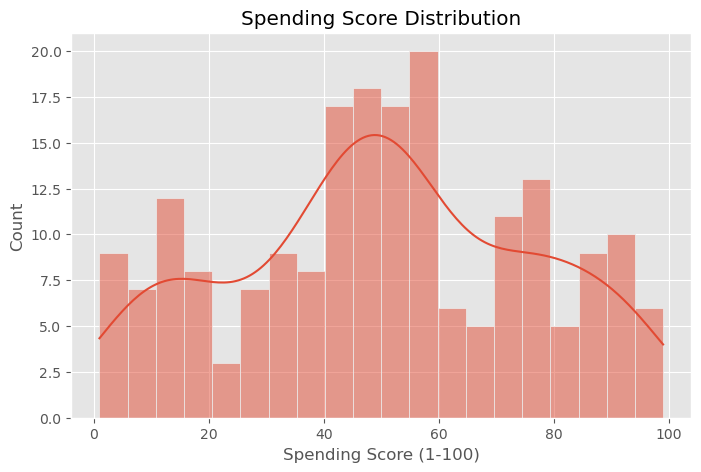

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Spending Score (1-100)"],
    bins=20,
    kde=True
)

plt.title("Spending Score Distribution")

plt.show()

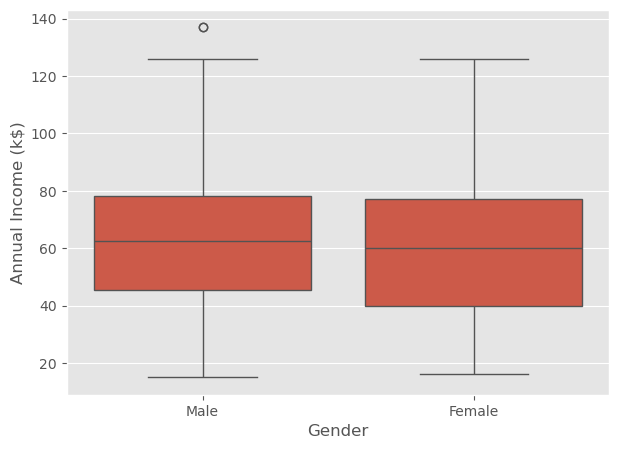

In [12]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Annual Income (k$)"
)

plt.show()

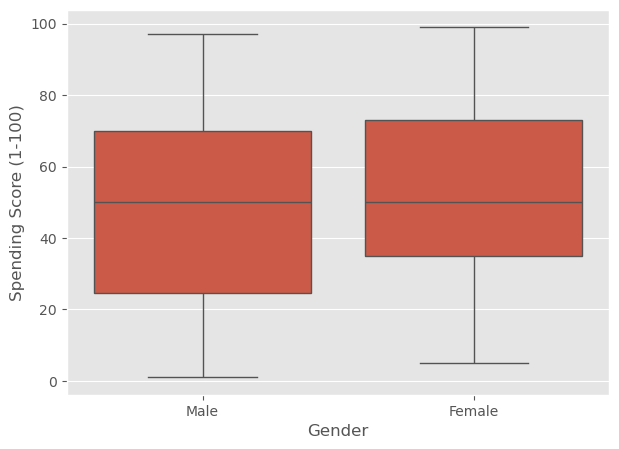

In [13]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Spending Score (1-100)"
)

plt.show()

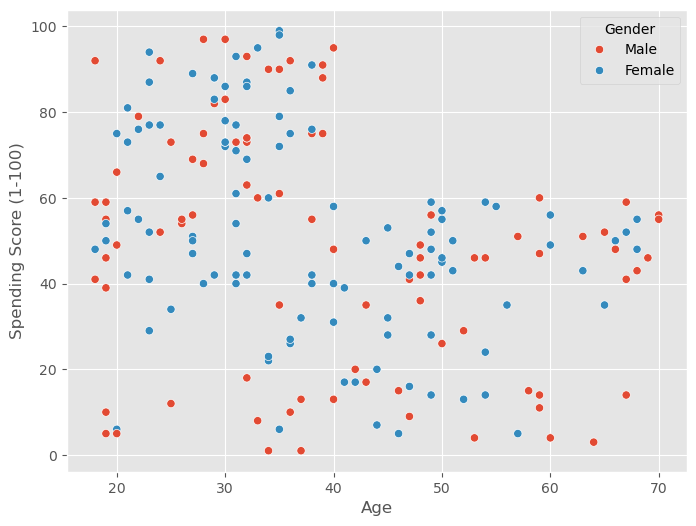

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=df,

    x="Age",

    y="Spending Score (1-100)",

    hue="Gender"

)

plt.show()

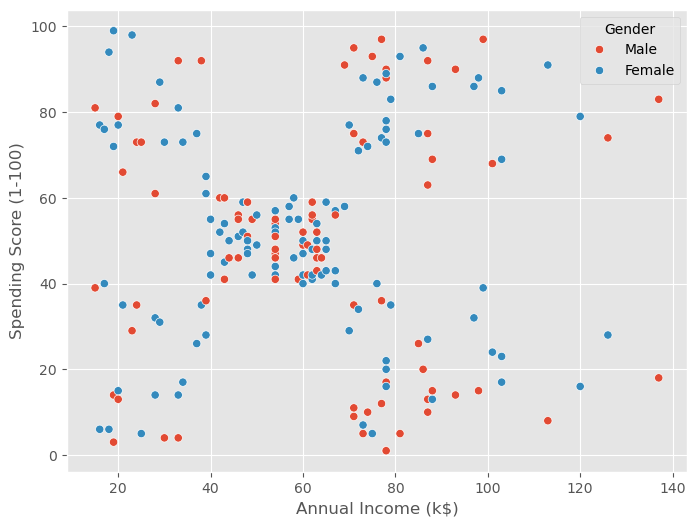

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=df,

    x="Annual Income (k$)",

    y="Spending Score (1-100)",

    hue="Gender"

)

plt.show()

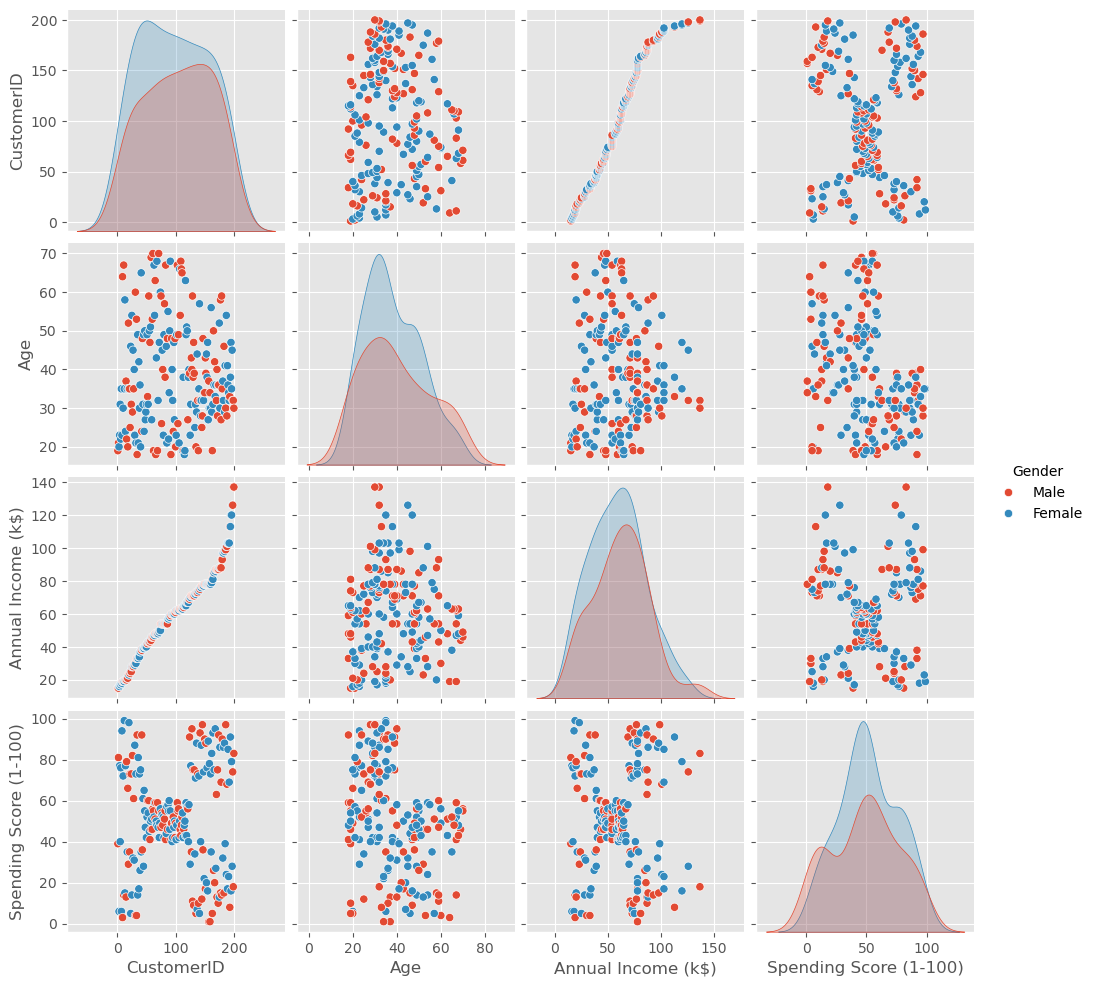

In [16]:
sns.pairplot(

    df,

    hue="Gender"

)

plt.show()

In [17]:
df_corr = df.copy()

df_corr["Gender"] = df_corr["Gender"].map({

    "Male":1,

    "Female":0

})

In [18]:
corr = df_corr.corr(numeric_only=True)

corr

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,0.057400,-0.026763,0.977548,0.013835
Gender,0.057400,1.000000,0.060867,0.056410,-0.058109
Age,-0.026763,0.060867,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,0.056410,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.058109,-0.327227,0.009903,1.000000


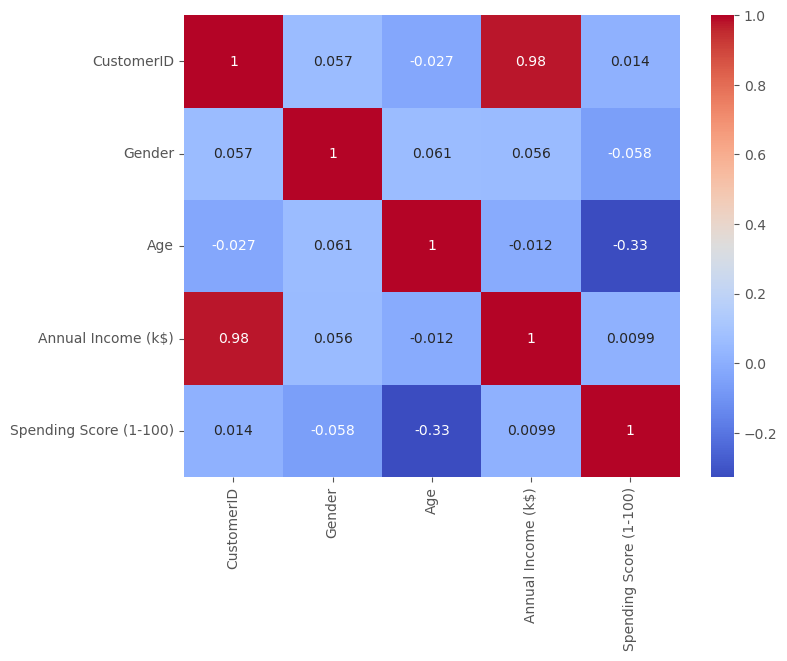

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(

    corr,

    annot=True,

    cmap="coolwarm"

)

plt.show()

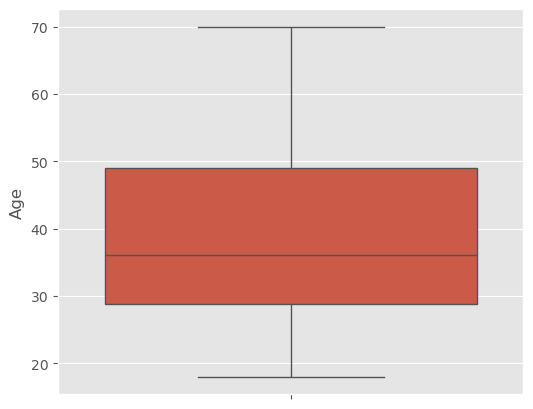

In [20]:
plt.figure(figsize=(6,5))

sns.boxplot(

    y=df["Age"]

)

plt.show()

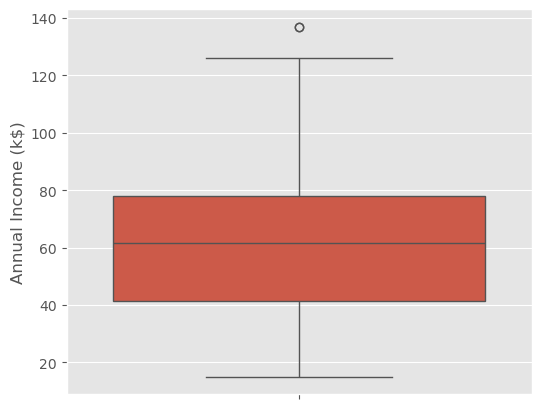

In [21]:
plt.figure(figsize=(6,5))

sns.boxplot(

    y=df["Annual Income (k$)"]

)

plt.show()

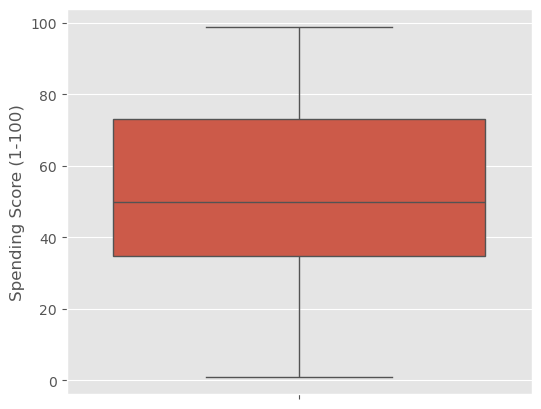

In [22]:
plt.figure(figsize=(6,5))

sns.boxplot(

    y=df["Spending Score (1-100)"]

)

plt.show()

In [23]:
print("Age")

print("Mean :",df["Age"].mean())

print("Median :",df["Age"].median())

print("Mode :",df["Age"].mode()[0])

print()

print("Income")

print("Mean :",df["Annual Income (k$)"].mean())

print("Median :",df["Annual Income (k$)"].median())

print("Mode :",df["Annual Income (k$)"].mode()[0])

print()

print("Spending Score")

print("Mean :",df["Spending Score (1-100)"].mean())

print("Median :",df["Spending Score (1-100)"].median())

print("Mode :",df["Spending Score (1-100)"].mode()[0])

Age
Mean : 38.85
Median : 36.0
Mode : 32

Income
Mean : 60.56
Median : 61.5
Mode : 54

Spending Score
Mean : 50.2
Median : 50.0
Mode : 42


In [24]:
print(df[["Age",

          "Annual Income (k$)",

          "Spending Score (1-100)"]].var())

print()

print(df[["Age",

          "Annual Income (k$)",

          "Spending Score (1-100)"]].std())

Age                       195.133166
Annual Income (k$)        689.835578
Spending Score (1-100)    666.854271
dtype: float64

Age                       13.969007
Annual Income (k$)        26.264721
Spending Score (1-100)    25.823522
dtype: float64


In [25]:
print(df[["Age",

          "Annual Income (k$)",

          "Spending Score (1-100)"]].skew())

print()

print(df[["Age",

          "Annual Income (k$)",

          "Spending Score (1-100)"]].kurt())

Age                       0.485569
Annual Income (k$)        0.321843
Spending Score (1-100)   -0.047220
dtype: float64

Age                      -0.671573
Annual Income (k$)       -0.098487
Spending Score (1-100)   -0.826629
dtype: float64


In [26]:
mean = df["Annual Income (k$)"].mean()

std = df["Annual Income (k$)"].std()

n = len(df)

margin = 1.96 * (std/np.sqrt(n))

print("95% Confidence Interval")

print(mean-margin)

print(mean+margin)

95% Confidence Interval
56.91989536138032
64.20010463861968


In [27]:
male = df[df["Gender"]=="Male"]["Annual Income (k$)"]

female = df[df["Gender"]=="Female"]["Annual Income (k$)"]

t,p = stats.ttest_ind(

    male,

    female

)

print("T Statistic :",t)

print("P Value :",p)

T Statistic : 0.795022298602198
P Value : 0.42755249399927864


In [28]:
if p < 0.05:

    print("Income differs significantly between male and female customers.")

else:

    print("No statistically significant difference in income between genders.")

No statistically significant difference in income between genders.


In [29]:
print("""

EDA Observations

• Customer ages range from young adults to senior citizens.

• Annual income is moderately distributed.

• Spending scores vary significantly.

• Income alone does not determine spending behavior.

• Customer segmentation is expected to reveal hidden purchasing patterns.

""")



EDA Observations

• Customer ages range from young adults to senior citizens.

• Annual income is moderately distributed.

• Spending scores vary significantly.

• Income alone does not determine spending behavior.

• Customer segmentation is expected to reveal hidden purchasing patterns.




In [30]:
features = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

features.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [31]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

In [32]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    wcss.append(model.inertia_)

C:\Users\Manav\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Manav\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Manav\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Manav\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

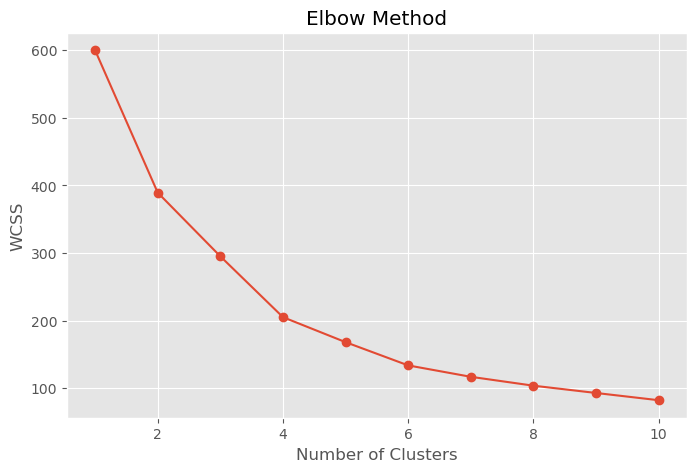

In [33]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [34]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_features)

df["Cluster"] = clusters

C:\Users\Manav\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [35]:
df["Cluster"].value_counts().sort_index()

Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

In [36]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    scaled_features,
    clusters
)

print("Silhouette Score :", score)

Silhouette Score : 0.41664341513732767


In [37]:
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

cluster_centers = pd.DataFrame(
    centers,
    columns=[
        "Age",
        "Annual Income",
        "Spending Score"
    ]
)

cluster_centers

,Age,Annual Income,Spending Score
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


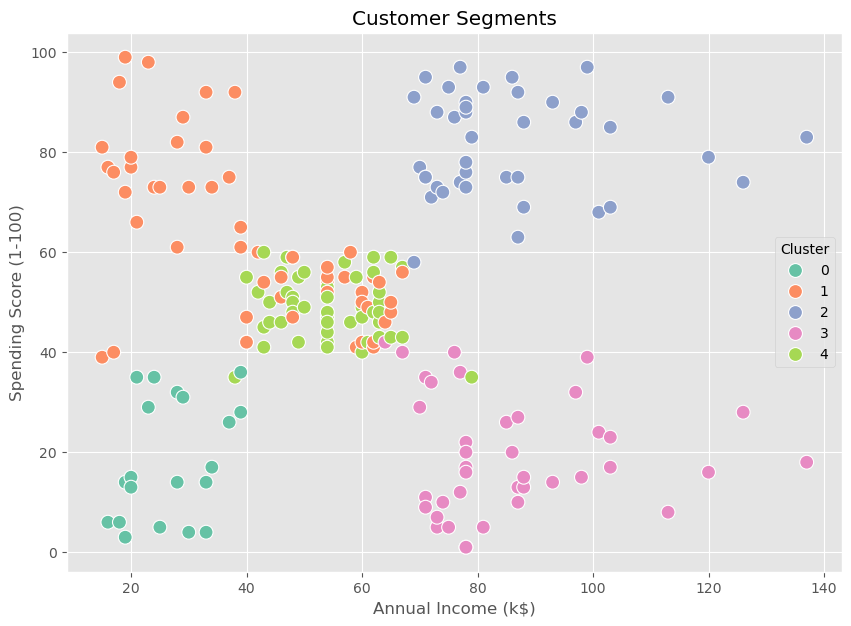

In [38]:
plt.figure(figsize=(10,7))

sns.scatterplot(

    data=df,

    x="Annual Income (k$)",

    y="Spending Score (1-100)",

    hue="Cluster",

    palette="Set2",

    s=100

)

plt.title("Customer Segments")

plt.show()

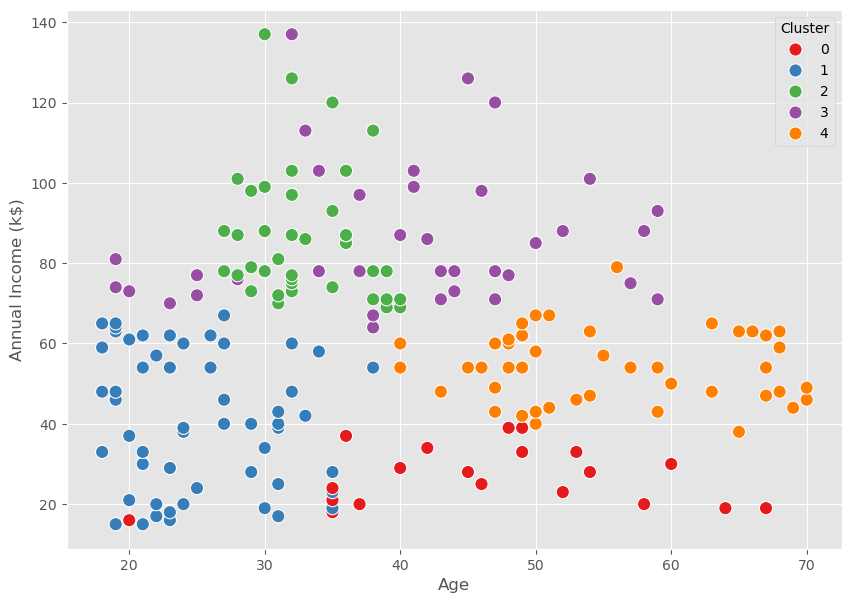

In [39]:
plt.figure(figsize=(10,7))

sns.scatterplot(

    data=df,

    x="Age",

    y="Annual Income (k$)",

    hue="Cluster",

    palette="Set1",

    s=90

)

plt.show()

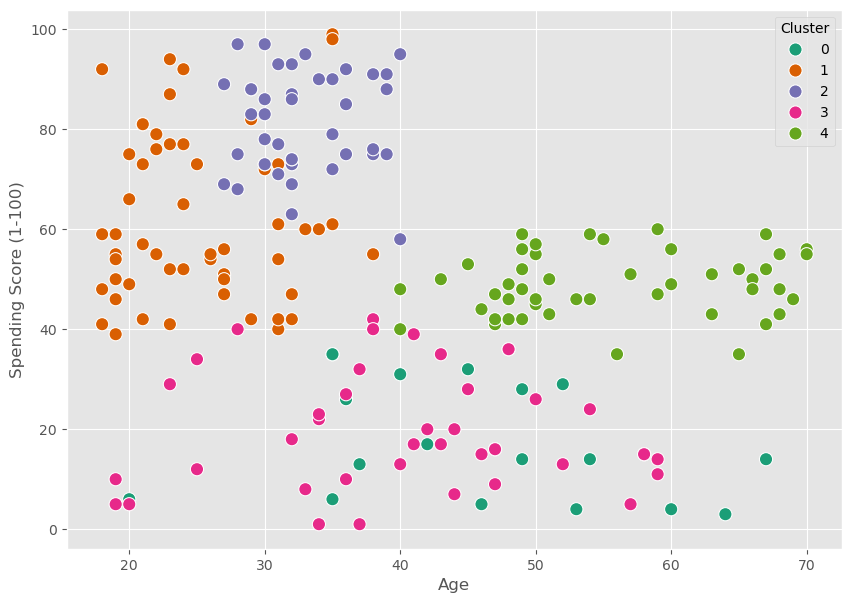

In [40]:
plt.figure(figsize=(10,7))

sns.scatterplot(

    data=df,

    x="Age",

    y="Spending Score (1-100)",

    hue="Cluster",

    palette="Dark2",

    s=90

)

plt.show()

C:\Users\Manav\AppData\Local\Temp\ipykernel_30040\833327674.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


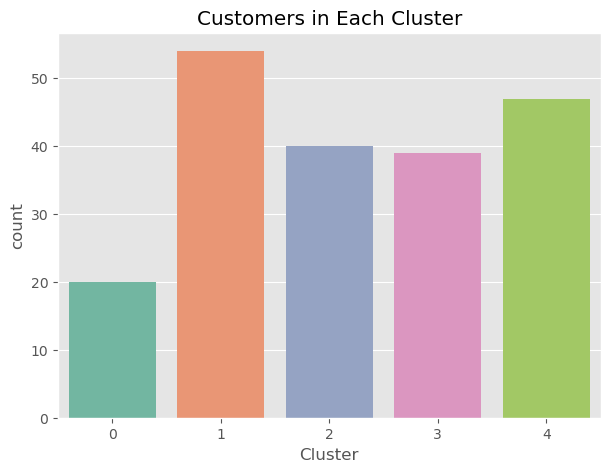

In [41]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Cluster",
    palette="Set2"
)

plt.title("Customers in Each Cluster")

plt.show()

In [42]:
profile = df.groupby("Cluster")[

    [

        "Age",

        "Annual Income (k$)",

        "Spending Score (1-100)"

    ]

].mean()

profile.round(2)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.25,26.75,18.35
1,25.19,41.09,62.24
2,32.88,86.10,81.53
3,39.87,86.10,19.36
4,55.64,54.38,48.85


In [43]:
profile["Customer Count"] = df.groupby(
    "Cluster"
).size()

profile

,Age,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster,,,,
0,46.250000,26.750000,18.350000,20
1,25.185185,41.092593,62.240741,54
2,32.875000,86.100000,81.525000,40
3,39.871795,86.102564,19.358974,39
4,55.638298,54.382979,48.851064,47


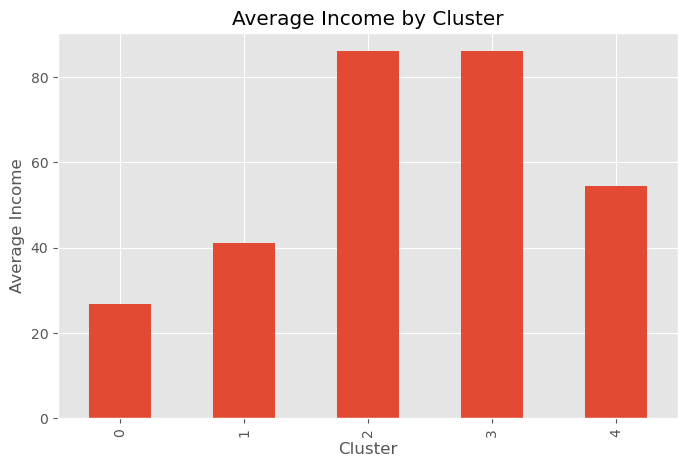

In [44]:
plt.figure(figsize=(8,5))

profile["Annual Income (k$)"].plot(
    kind="bar"
)

plt.ylabel("Average Income")

plt.title("Average Income by Cluster")

plt.show()

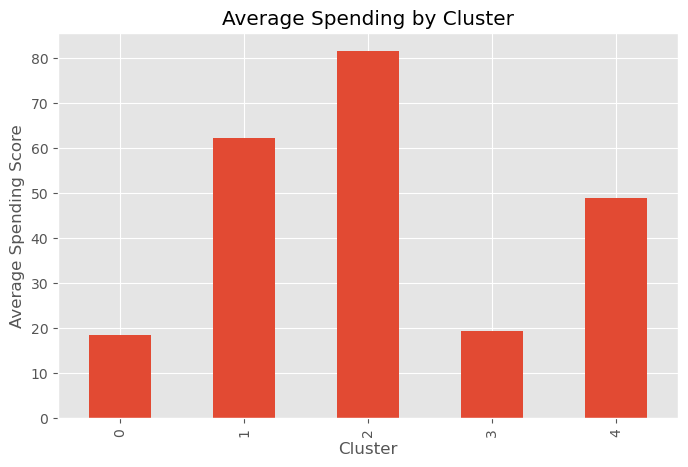

In [45]:
plt.figure(figsize=(8,5))

profile["Spending Score (1-100)"].plot(
    kind="bar"
)

plt.ylabel("Average Spending Score")

plt.title("Average Spending by Cluster")

plt.show()

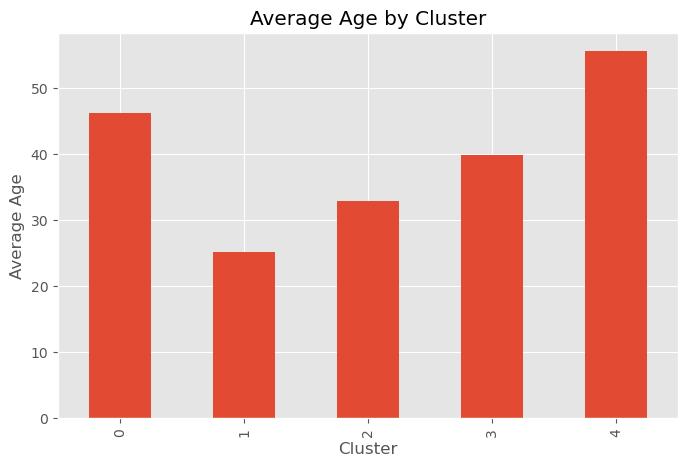

In [46]:
plt.figure(figsize=(8,5))

profile["Age"].plot(
    kind="bar"
)

plt.ylabel("Average Age")

plt.title("Average Age by Cluster")

plt.show()

In [47]:
cluster_names = {

    0:"Premium Customers",

    1:"Budget Customers",

    2:"Young Spenders",

    3:"Careful Customers",

    4:"Average Customers"

}

df["Customer Segment"] = df["Cluster"].map(
    cluster_names
)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,1,Male,19,15,39,1,Budget Customers
1,2,Male,21,15,81,1,Budget Customers
2,3,Female,20,16,6,0,Premium Customers
3,4,Female,23,16,77,1,Budget Customers
4,5,Female,31,17,40,1,Budget Customers


In [48]:
df["Customer Segment"].value_counts()

Customer Segment
Budget Customers     54
Average Customers    47
Young Spenders       40
Careful Customers    39
Premium Customers    20
Name: count, dtype: int64

In [49]:
segment_summary = df.groupby(
    "Customer Segment"
)[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].mean()

segment_summary.round(2)

,Age,Annual Income (k$),Spending Score (1-100)
Customer Segment,,,
Average Customers,55.64,54.38,48.85
Budget Customers,25.19,41.09,62.24
Careful Customers,39.87,86.10,19.36
Premium Customers,46.25,26.75,18.35
Young Spenders,32.88,86.10,81.53


In [50]:
print("""

Customer Profiling Completed

✔ Five unique customer segments identified.

✔ Customers differ significantly in income and spending.

✔ High-income customers are not always high spenders.

✔ Segmentation enables personalized marketing.

✔ Customer profiling helps improve retention.

""")



Customer Profiling Completed

✔ Five unique customer segments identified.

✔ Customers differ significantly in income and spending.

✔ High-income customers are not always high spenders.

✔ Segmentation enables personalized marketing.

✔ Customer profiling helps improve retention.




In [51]:
df[[
    "CustomerID",
    "Gender",
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)",
    "Customer Segment"
]].head(15)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Customer Segment
0,1,Male,19,15,39,Budget Customers
1,2,Male,21,15,81,Budget Customers
2,3,Female,20,16,6,Premium Customers
3,4,Female,23,16,77,Budget Customers
4,5,Female,31,17,40,Budget Customers
5,6,Female,22,17,76,Budget Customers
6,7,Female,35,18,6,Premium Customers
7,8,Female,23,18,94,Budget Customers
8,9,Male,64,19,3,Premium Customers
9,10,Female,30,19,72,Budget Customers


In [52]:
summary = df.groupby("Customer Segment").agg({

    "Age":"mean",

    "Annual Income (k$)":"mean",

    "Spending Score (1-100)":"mean",

    "CustomerID":"count"

}).rename(columns={

    "CustomerID":"Customers"

})

summary.round(2)

,Age,Annual Income (k$),Spending Score (1-100),Customers
Customer Segment,,,,
Average Customers,55.64,54.38,48.85,47
Budget Customers,25.19,41.09,62.24,54
Careful Customers,39.87,86.10,19.36,39
Premium Customers,46.25,26.75,18.35,20
Young Spenders,32.88,86.10,81.53,40


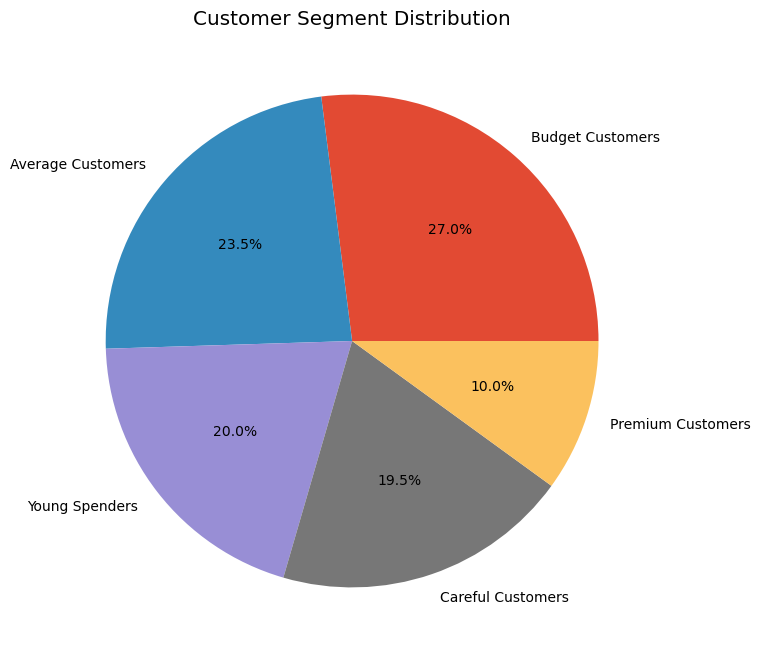

In [53]:
plt.figure(figsize=(8,8))

df["Customer Segment"].value_counts().plot(

    kind="pie",

    autopct="%1.1f%%"

)

plt.ylabel("")

plt.title("Customer Segment Distribution")

plt.show()

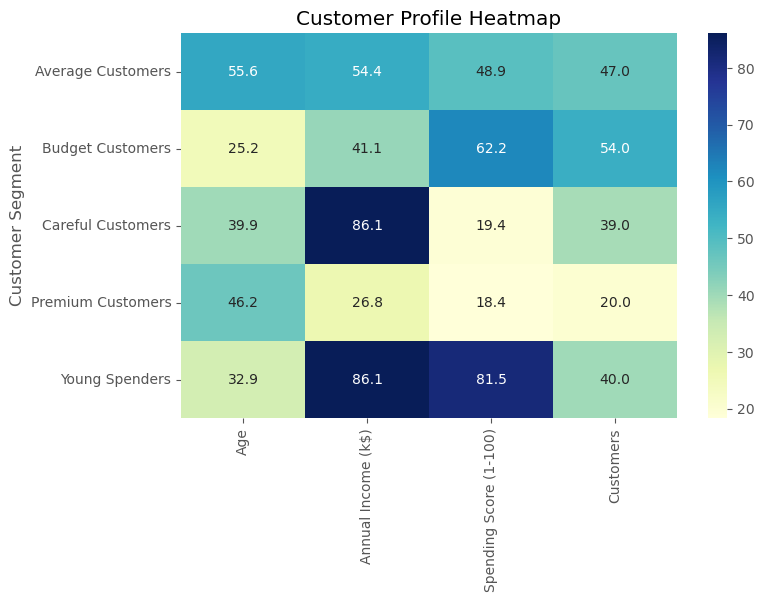

In [54]:
plt.figure(figsize=(8,5))

sns.heatmap(

    summary,

    annot=True,

    cmap="YlGnBu",

    fmt=".1f"

)

plt.title("Customer Profile Heatmap")

plt.show()

In [55]:
for segment in summary.index:

    print("="*60)

    print(segment)

    print(summary.loc[segment])

    print()

Average Customers
Age                       55.638298
Annual Income (k$)        54.382979
Spending Score (1-100)    48.851064
Customers                 47.000000
Name: Average Customers, dtype: float64

Budget Customers
Age                       25.185185
Annual Income (k$)        41.092593
Spending Score (1-100)    62.240741
Customers                 54.000000
Name: Budget Customers, dtype: float64

Careful Customers
Age                       39.871795
Annual Income (k$)        86.102564
Spending Score (1-100)    19.358974
Customers                 39.000000
Name: Careful Customers, dtype: float64

Premium Customers
Age                       46.25
Annual Income (k$)        26.75
Spending Score (1-100)    18.35
Customers                 20.00
Name: Premium Customers, dtype: float64

Young Spenders
Age                       32.875
Annual Income (k$)        86.100
Spending Score (1-100)    81.525
Customers                 40.000
Name: Young Spenders, dtype: float64



In [56]:
print("""

Customer Personas

Premium Customers
• High Income
• High Spending
• Valuable customers

Budget Customers
• Low Income
• Low Spending
• Price-sensitive

Young Spenders
• Young customers
• High shopping frequency
• Influenced by trends

Careful Customers
• High income
• Low spending
• Potential future customers

Average Customers
• Moderate income
• Moderate spending
• Stable customers

""")



Customer Personas

Premium Customers
• High Income
• High Spending
• Valuable customers

Budget Customers
• Low Income
• Low Spending
• Price-sensitive

Young Spenders
• Young customers
• High shopping frequency
• Influenced by trends

Careful Customers
• High income
• Low spending
• Potential future customers

Average Customers
• Moderate income
• Moderate spending
• Stable customers




In [57]:
strategies = pd.DataFrame({

"Customer Segment":[

"Premium Customers",

"Budget Customers",

"Young Spenders",

"Careful Customers",

"Average Customers"

],

"Marketing Strategy":[

"VIP Membership & Exclusive Rewards",

"Coupons & Discounts",

"Social Media Campaigns",

"Personalized Offers",

"Loyalty Programs"

]

})

strategies

,Customer Segment,Marketing Strategy
0,Premium Customers,VIP Membership & Exclusive Rewards
1,Budget Customers,Coupons & Discounts
2,Young Spenders,Social Media Campaigns
3,Careful Customers,Personalized Offers
4,Average Customers,Loyalty Programs


In [58]:
print("""

Business Recommendations

✔ Offer premium memberships to high-value customers.

✔ Launch targeted discounts for budget-conscious customers.

✔ Advertise trendy products to young shoppers.

✔ Convert careful customers into active buyers with personalized offers.

✔ Improve loyalty programs for average customers.

✔ Use customer segmentation for email marketing.

✔ Recommend products based on customer segment.

✔ Allocate marketing budget according to segment value.

""")



Business Recommendations

✔ Offer premium memberships to high-value customers.

✔ Launch targeted discounts for budget-conscious customers.

✔ Advertise trendy products to young shoppers.

✔ Convert careful customers into active buyers with personalized offers.

✔ Improve loyalty programs for average customers.

✔ Use customer segmentation for email marketing.

✔ Recommend products based on customer segment.

✔ Allocate marketing budget according to segment value.




In [59]:
df.to_csv(

    "Customer_Segments_Output.csv",

    index=False

)

print("Clustered dataset saved successfully.")

Clustered dataset saved successfully.


In [60]:
import joblib

joblib.dump(

    kmeans,

    "customer_segmentation_model.pkl"

)

print("Model saved successfully.")

Model saved successfully.


In [61]:
loaded_model = joblib.load(

    "customer_segmentation_model.pkl"

)

print("Model loaded successfully.")

Model loaded successfully.


In [62]:
new_customer = pd.DataFrame({

    "Age":[28],

    "Annual Income (k$)":[72],

    "Spending Score (1-100)":[80]

})

scaled_customer = scaler.transform(new_customer)

cluster = loaded_model.predict(scaled_customer)

print("Predicted Cluster :",cluster[0])

Predicted Cluster : 2


In [63]:
predicted_segment = cluster_names.get(

    cluster[0],

    "Unknown"

)

print("Customer Segment :",predicted_segment)

Customer Segment : Young Spenders


In [64]:
print("""

PROJECT CONCLUSION

✔ Customer data successfully analyzed.

✔ Five customer segments identified using K-Means Clustering.

✔ Customer profiling completed.

✔ Targeted marketing strategies developed.

✔ Business recommendations generated.

✔ Customer segmentation model saved successfully.

Project Completed Successfully.

""")



PROJECT CONCLUSION

✔ Customer data successfully analyzed.

✔ Five customer segments identified using K-Means Clustering.

✔ Customer profiling completed.

✔ Targeted marketing strategies developed.

✔ Business recommendations generated.

✔ Customer segmentation model saved successfully.

Project Completed Successfully.




In [65]:
final_summary = pd.DataFrame({

    "Dataset":[

        "Mall Customers"

    ],

    "Rows":[

        df.shape[0]

    ],

    "Columns":[

        df.shape[1]

    ],

    "Algorithm":[

        "K-Means Clustering"

    ],

    "Number of Clusters":[

        len(df["Cluster"].unique())

    ],

    "Silhouette Score":[

        round(score,3)

    ]

})

final_summary

,Dataset,Rows,Columns,Algorithm,Number of Clusters,Silhouette Score
0,Mall Customers,200,7,K-Means Clustering,5,0.417
